In [2]:
# Install dependencies
!pip install -q seqeval

# Core imports
import os
from datetime import datetime
import numpy as np
import pandas as pd
import torch
from collections import Counter

from datasets import DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)
from seqeval.metrics import classification_report

# Import utility functions
from ner_utility_funcs import (
    load_swedish_medical_ner,
    split_and_preprocess,
    build_label_schema,
    make_to_features,
    make_compute_metrics,
    extract_entities,
)


print("Imports OK")

Imports OK


In [3]:
# Configuration
MODEL_NAME = "KB/bert-base-swedish-cased"
CONFIGS = ["1177"]  # Only use gold-standard data
VAL_FRACTION = 0.05
SEED = 42
MAX_LENGTH = 256

# Set seed for reproducibility
from transformers import set_seed
set_seed(SEED)

In [4]:
# Load dataset
datasets = load_swedish_medical_ner(configs=CONFIGS, cache_dir="data")

# Split and preprocess (removes brackets, normalizes entities)
per_source = split_and_preprocess(datasets, val_fraction=VAL_FRACTION, seed=SEED)

# Show stats
for config, ds in per_source.items():
    print(f"{config}: {len(ds['train'])} train, {len(ds['validation'])} val")

README.md: 0.00B [00:00, ?B/s]

1177/train-00000-of-00001.parquet:   0%|          | 0.00/77.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/927 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/927 [00:00<?, ? examples/s]

Processing 1177...


1177/train:   0%|          | 0/880 [00:00<?, ? examples/s]

1177/val:   0%|          | 0/47 [00:00<?, ? examples/s]

Map:   0%|          | 0/880 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

1177: 880 train, 47 val


## Task 1: Survey of Language Models for Swedish Biomedical NER

### 1.1 Problem Context

Named Entity Recognition (NER) in Swedish biomedical text presents unique challenges. Swedish is a low-resource language compared to English, and clinical text contains specialized vocabulary, abbreviations, and domain-specific conventions that differ significantly from general-domain text (Almgren & Pavlov, 2016). The task requires identifying three entity types: **Disorder and Finding** (sjukdom & symtom), **Pharmaceutical Drug** (läkemedel), and **Body Structure** (kroppsdel).

Two fundamental approaches exist for this task:

1. **Fine-tune a Swedish language model** on biomedical NER data
2. **Translate Swedish text to English** and use domain-specific English models (e.g., BioBERT, Clinical-BERT)

### 1.2 Available Models

| Model              | Language                 | Domain     | Training Data                              | Availability            |
| ------------------ | ------------------------ | ---------- | ------------------------------------------ | ----------------------- |
| **KB-BERT**        | Swedish                  | General    | 18.3 GB (news, books, Wikipedia, gov docs) | ✅ Public (Hugging Face) |
| **M-BERT**         | Multilingual (104 langs) | General    | Wikipedia                                  | ✅ Public                |
| **SweDeClin-BERT** | Swedish                  | Clinical   | 17.9 GB EHRs (~2M records)                 | ❌ Restricted access     |
| **BioBERT**        | English                  | Biomedical | PubMed abstracts (21.3B words)             | ✅ Public                |
| **Clinical-BERT**  | English                  | Clinical   | MIMIC-III (112K EHRs)                      | ✅ Public                |

### 

### 1.3 Performance Comparison

Rosvall & Paasonen (2023) systematically compared these models on the Stockholm EPR PHI Corpus for Swedish clinical NER:

| Model                          | F1-Score (Full Data) | Notes                                            |
| ------------------------------ | -------------------- | ------------------------------------------------ |
| **SweDeClin-BERT**             | ~0.94                | Best overall, especially for small datasets      |
| **KB-BERT**                    | ~0.91                | Strong second, good generalization               |
| **M-BERT**                     | ~0.88                | Decent but underperforms Swedish-specific models |
| **BioBERT** (translated)       | ~0.82                | Translation errors degrade performance           |
| **Clinical-BERT** (translated) | ~0.80                | Domain match helps, but translation hurts        |

Key findings:

- **SweDeClin-BERT** excels due to pre-training on Swedish clinical text, capturing domain-specific terminology and abbreviations
- **KB-BERT** performs well despite being general-domain, benefiting from extensive Swedish pre-training
- **Translation-based approaches** (BioBERT, Clinical-BERT) suffer from translation artifacts, particularly for clinical abbreviations and compound words

### 1.4 Trade-off Analysis: Swedish LLM vs. Translation Approach

| Aspect                     | Swedish LLM (KB-BERT)                              | Translation + English Model                    |
| -------------------------- | -------------------------------------------------- | ---------------------------------------------- |
| **Linguistic fidelity**    | ✅ Native handling of Swedish morphology, compounds | ❌ Translation errors, especially abbreviations |
| **Domain knowledge**       | ⚠️ General domain (requires fine-tuning)            | ✅ Pre-trained on biomedical/clinical text      |
| **Pipeline complexity**    | ✅ Single model                                     | ❌ Translation + NER + back-mapping             |
| **Error propagation**      | ✅ Minimal                                          | ❌ Translation errors cascade to NER            |
| **Clinical abbreviations** | ✅ Can learn Swedish-specific forms                 | ❌ "SSK" → nurse fails to translate             |
| **Reproducibility**        | ✅ End-to-end                                       | ⚠️ Depends on translation model version         |

### 1.5 The SweDeClin-BERT Question

SweDeClin-BERT (Vakili et al.) achieves the highest reported performance on Swedish clinical NER. However, it is trained on sensitive EHR data from Swedish hospitals and is **not publicly available**. Access requires application to the Swedish Health Record Research Bank and institutional agreements, making it impractical for this project.

### 1.6 Summary

For Swedish biomedical NER, the evidence suggests:

1. **Swedish-specific models outperform multilingual models** — linguistic specialization matters
2. **Translation-based approaches introduce unacceptable error rates** — clinical abbreviations and terminology do not translate reliably
3. **Domain-specific pre-training helps significantly** — but requires access to restricted clinical data
4. **KB-BERT is the best publicly available option** — strong Swedish language understanding can compensate for lack of domain-specific pre-training through task-specific fine-tuning


## Task 2: Model Selection and Justification

### 2.1 Selected Model: KB-BERT (`KB/bert-base-swedish-cased`)

We select **KB-BERT** (Malmsten et al., 2020) as our base model for Swedish biomedical NER.

### 2.2 Justification

**1. Best available Swedish language understanding**

KB-BERT was trained on 18.3 GB of Swedish text spanning diverse sources (news, literature, government documents, Wikipedia). This provides robust understanding of Swedish grammar, morphology, and vocabulary — a foundation that transfer learning can adapt to the biomedical domain.

Grancharova & Dalianis (2021) showed KB-BERT achieves F1=0.92 on Swedish clinical NER, outperforming M-BERT despite no clinical pre-training.

**2. Public availability and reproducibility**

Unlike SweDeClin-BERT (the theoretical best choice), KB-BERT is freely available on Hugging Face without access restrictions. This enables:

- Full reproducibility of experiments
- Use in downstream applications without licensing constraints
- Community building and comparison with other researchers

**3. Proven NER capability**

The KB team has released a general-domain NER variant (`KB/bert-base-swedish-cased-ner`) fine-tuned on SUC 3.0. While this targets different entity types (PER, LOC, ORG), it demonstrates the architecture's suitability for Swedish sequence labeling.

**4. Translation approach rejected**

We explicitly reject the BioBERT/Clinical-BERT translation approach because:

- Clinical abbreviations (e.g., "hö" for "höger", "SSK" for nurse) do not translate correctly
- Compound words are common in Swedish medical text and often mistranslated
- The translation pipeline adds complexity and potential failure points
- Rosvall & Paasonen (2023) found translated approaches underperform by ~10 F1 points

### 2.3 Limitations and Mitigations

| Limitation                    | Mitigation                                      |
| ----------------------------- | ----------------------------------------------- |
| No clinical pre-training      | Fine-tune on domain-specific data (1177 subset) |
| General vocabulary            | BIO tagging allows learning new entity spans    |
| Limited medical abbreviations | Training data from 1177.se uses full terms      |

### 2.4 Alternative Considered: Multilingual BERT

M-BERT was considered as a fallback option given its multilingual capabilities. However:

- It underperforms KB-BERT on Swedish tasks consistently
- The Swedish portion of its training data is limited to Wikipedia
- No benefit from cross-lingual transfer for our monolingual task


### 2.5 Conclusion

KB-BERT represents the optimal trade-off between performance, availability, and reproducibility for Swedish biomedical NER. While SweDeClin-BERT would theoretically perform better, its restricted access makes it unsuitable. Fine-tuning KB-BERT on the 1177 gold-standard subset should yield strong results for our clinical entity extraction task.

------

## 

## References

- Almgren, S., & Pavlov, S. (2016). *Named Entity Recognition in Swedish Medical Journals*. Chalmers University of Technology.
- Grancharova, M., & Dalianis, H. (2021). Comparing BERT Models for Clinical NER on Swedish Electronic Health Records. *CEUR Workshop Proceedings*.
- Malmsten, M., Börjeson, L., & Haffenden, C. (2020). Playing with Words at the National Library of Sweden. *arXiv:2007.01658*.
- Rosvall, E., & Paasonen, A. (2023). *Data Augmentation for Swedish Clinical NER*. Chalmers University of Technology.
- Vakili, T., et al. (2022). SweDeClin-BERT: A Swedish Clinical BERT Model. *Swedish Health Record Research Bank*.

## Data Exploration

Before training, we explore the Swedish Medical NER dataset to understand its structure, annotation scheme, and characteristics. This informs our preprocessing and training decisions.

### Dataset Background

The Swedish Medical NER dataset (Almgren & Pavlov, 2016) was created from three sources:

| Source | Description | Annotation Method | Size |
|--------|-------------|-------------------|------|
| **1177** | Articles from 1177.se (Swedish healthcare portal) | Manual annotation by domain experts | ~900 sentences |
| **lt** | Läkartidningen (Swedish medical journal) | Distant supervision (automatic) | ~750k sentences |
| **wiki** | Swedish Wikipedia medical articles | Distant supervision (automatic) | ~50k sentences |



In [10]:
#DELETE from here?
# Load all three configs to compare them
from ner_utility_funcs import load_swedish_medical_ner, normalize_entities

all_datasets = load_swedish_medical_ner(configs=["1177", "lt", "wiki"], cache_dir="data")

# Quick overview
print("DATASET SIZES:")
print("-" * 40)
for ds in all_datasets:
    print(f"{ds.config_name:6}: {len(ds['train']):>8,} sentences")

Loading 1177 from disk cache...


lt/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/745753 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/745753 [00:00<?, ? examples/s]

wiki/train-00000-of-00001.parquet:   0%|          | 0.00/2.57M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/48720 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/48720 [00:00<?, ? examples/s]

DATASET SIZES:
----------------------------------------
1177  :      927 sentences
lt    :  745,753 sentences
wiki  :   48,720 sentences


In [11]:
# Compare annotation patterns across the three configs
print("COMPARING ANNOTATION PATTERNS ACROSS CONFIGS:")
print("=" * 70)

for ds in all_datasets:
    config = ds.config_name
    print(f"\n{'='*20} {config.upper()} {'='*20}")
    
    # Show 5 random examples with entities
    examples_with_entities = [ex for ex in ds["train"] if len(normalize_entities(ex)["entities"]) > 0][:10]
    
    for i, ex in enumerate(examples_with_entities[:5]):
        norm = normalize_entities(ex)
        sent = ex["sentence"]
        ents = norm["entities"]
        
        print(f"\n[{i+1}] {sent[:100]}...")
        for e in ents[:3]:  # Show first 3 entities
            # Show the actual span in context
            start, end = e["start"], e["end"]
            context_start = max(0, start - 10)
            context_end = min(len(sent), end + 10)
            context = sent[context_start:context_end]
            
            type_name = ["Disorder", "Drug", "Body"][e["type"]]
            print(f"    {type_name}: '{e['text']}' | context: '...{context}...'")

COMPARING ANNOTATION PATTERNS ACROSS CONFIGS:

==================== 1177 ====================

[1] Memantin ( Ebixa ) ger sällan några biverkningar....
    Disorder: 'Ebixa' | context: '...Memantin ( Ebixa ) ger sälla...'

[2] Det är också lättare att dosera [ flytande medicin ] än att dela på tabletter....
    Drug: 'flytande medicin' | context: '...tt dosera [ flytande medicin ] än att de...'

[3] ( Förstoppning ) är ett vanligt problem hos äldre....
    Disorder: 'Förstoppning' | context: '...( Förstoppning ) är ett va...'

[4] [ Medicinen ] kan också göra att man blöder lättare eftersom den påverkar { blodets } förmåga att le...
    Drug: 'Medicinen' | context: '...[ Medicinen ] kan också...'
    Body: 'blodets' | context: '... påverkar { blodets } förmåga a...'

[5] För att få ett skydd mot ( hepatit B ) behövs tre doser vaccin....
    Disorder: 'hepatit B' | context: '...skydd mot ( hepatit B ) behövs tr...'

==================== LT ====================

[1] , (hjärtinfarkt) och 

In [15]:
# Fix: iterate properly over HuggingFace dataset
print("BRACKET USAGE BY CONFIG:")
print("-" * 50)

for ds in all_datasets:
    config = ds.config_name
    bracket_counts = {"()": 0, "[]": 0, "{}": 0, "none": 0}
    
    # Use select() for proper slicing
    sample = ds["train"].select(range(min(1000, len(ds["train"]))))
    
    for ex in sample:
        sent = ex["sentence"]
        if "(" in sent and ")" in sent:
            bracket_counts["()"] += 1
        if "[" in sent and "]" in sent:
            bracket_counts["[]"] += 1
        if "{" in sent and "}" in sent:
            bracket_counts["{}"] += 1
        if not any(b in sent for b in "()[]{}"):
            bracket_counts["none"] += 1
    
    print(f"\n{config} (n={len(sample)}):")
    for bracket, count in bracket_counts.items():
        pct = count / len(sample) * 100
        print(f"  {bracket}: {count} ({pct:.1f}%)")

BRACKET USAGE BY CONFIG:
--------------------------------------------------

1177 (n=927):
  (): 316 (34.1%)
  []: 296 (31.9%)
  {}: 155 (16.7%)
  none: 342 (36.9%)

lt (n=1000):
  (): 539 (53.9%)
  []: 160 (16.0%)
  {}: 343 (34.3%)
  none: 64 (6.4%)

wiki (n=1000):
  (): 269 (26.9%)
  []: 42 (4.2%)
  {}: 923 (92.3%)
  none: 0 (0.0%)


In [14]:
# Check for annotation errors: Body parts labeled as Disorder
print("\nPOTENTIAL ANNOTATION ERRORS:")
print("Body Structure terms labeled as Disorder/Drug")
print("-" * 60)

body_terms = {"hjärta", "hjärtat", "lever", "njure", "hjärna", "lunga", "mage", 
              "hud", "ben", "muskel", "blod", "öga", "öra", "näsa", "arm", "ben",
              "fot", "hand", "finger", "kropp", "kroppen"}

for ds in all_datasets:
    config = ds.config_name
    errors = []
    
    for ex in ds["train"]:
        norm = normalize_entities(ex)
        for e in norm["entities"]:
            text = e["text"].lower().strip("()[]{}  ")
            if text in body_terms and e["type"] != 2:  # 2 = Body Structure
                type_name = ["Disorder", "Drug", "Body"][e["type"]]
                errors.append((text, type_name))
    
    error_counts = Counter(errors)
    print(f"\n{config}: {len(errors)} potential errors")
    for (text, wrong_type), count in error_counts.most_common(10):
        print(f"  '{text}' labeled as {wrong_type}: {count}x")


POTENTIAL ANNOTATION ERRORS:
Body Structure terms labeled as Disorder/Drug
------------------------------------------------------------

1177: 0 potential errors

lt: 10888 potential errors
  'blod' labeled as Disorder: 5714x
  'hjärtat' labeled as Disorder: 2432x
  'arm' labeled as Disorder: 1428x
  'fot' labeled as Disorder: 748x
  'mage' labeled as Disorder: 533x
  'hjärta' labeled as Disorder: 11x
  'ben' labeled as Disorder: 11x
  'hud' labeled as Disorder: 6x
  'blod' labeled as Drug: 3x
  'näsa' labeled as Disorder: 2x

wiki: 1002 potential errors
  'blod' labeled as Drug: 528x
  'hjärtat' labeled as Disorder: 397x
  'mage' labeled as Disorder: 67x
  'fot' labeled as Drug: 5x
  'hjärta' labeled as Disorder: 4x
  'ben' labeled as Drug: 1x


In [16]:
# Check: Entity text overlap between configs
# Do they label the same medical terms?
from collections import Counter

print("\nENTITY VOCABULARY OVERLAP:")
print("-" * 50)

entity_vocab = {}
for ds in all_datasets:
    config = ds.config_name
    texts = []
    for ex in ds["train"]:
        norm = normalize_entities(ex)
        for e in norm["entities"]:
            texts.append(e["text"].lower().strip("()[]{}  "))
    entity_vocab[config] = set(texts)
    print(f"{config}: {len(entity_vocab[config])} unique entity texts")

# Overlap
overlap_all = entity_vocab["1177"] & entity_vocab["lt"] & entity_vocab["wiki"]
print(f"\nShared across all three: {len(overlap_all)}")

overlap_1177_lt = entity_vocab["1177"] & entity_vocab["lt"]
print(f"Shared 1177 ∩ lt: {len(overlap_1177_lt)}")

overlap_1177_wiki = entity_vocab["1177"] & entity_vocab["wiki"]
print(f"Shared 1177 ∩ wiki: {len(overlap_1177_wiki)}")

# Show some shared terms
print(f"\nExamples of shared entities: {list(overlap_all)[:15]}")


ENTITY VOCABULARY OVERLAP:
--------------------------------------------------
1177: 462 unique entity texts
lt: 32774 unique entity texts
wiki: 8067 unique entity texts

Shared across all three: 84
Shared 1177 ∩ lt: 110
Shared 1177 ∩ wiki: 91

Examples of shared entities: ['citodon', 'mässling', 'vattkoppor', 'mage', 'budesonid', 'läkemedel', 'röda hund', 'njursjukdom', 'ibuprofen', 'inflammation', 'panocod', 'huden', 'reminyl', 'cox-hämmare', 'huvudvärk']


In [18]:
# Check: Same entity text, same type?
# This reveals annotation inconsistency
print("\nANNOTATION CONSISTENCY CHECK:")
print("Do configs assign the same type to the same entity text?")
print("-" * 60)

# Build entity_text -> type mapping for each config
type_names = ["Disorder", "Drug", "Body"]
entity_types = {config: {} for config in ["1177", "lt", "wiki"]}

for ds in all_datasets:
    config = ds.config_name
    for ex in ds["train"]:
        norm = normalize_entities(ex)
        for e in norm["entities"]:
            text = e["text"].lower().strip("()[]{}  ")
            entity_types[config][text] = type_names[e["type"]]

# Find inconsistencies
inconsistent = []
for text in overlap_all:
    types = {config: entity_types[config].get(text) for config in ["1177", "lt", "wiki"]}
    if len(set(types.values())) > 1:
        inconsistent.append((text, types))

print(f"\nInconsistent annotations (same text, different type): {len(inconsistent)}")
for text, types in inconsistent[:10]:
    print(f"  '{text}': {types}")


ANNOTATION CONSISTENCY CHECK:
Do configs assign the same type to the same entity text?
------------------------------------------------------------

Inconsistent annotations (same text, different type): 7
  'mage': {'1177': 'Body', 'lt': 'Disorder', 'wiki': 'Disorder'}
  'reminyl': {'1177': 'Drug', 'lt': 'Disorder', 'wiki': 'Drug'}
  'waran': {'1177': 'Drug', 'lt': 'Drug', 'wiki': 'Disorder'}
  'blod': {'1177': 'Body', 'lt': 'Disorder', 'wiki': 'Drug'}
  'tand': {'1177': 'Body', 'lt': 'Body', 'wiki': 'Disorder'}
  'näsan': {'1177': 'Body', 'lt': 'Disorder', 'wiki': 'Body'}
  'depression': {'1177': 'Disorder', 'lt': 'Body', 'wiki': 'Disorder'}


### Entity Types

The dataset annotates three entity types relevant to clinical text:

In [19]:
entity_info = pd.DataFrame({
    "Entity Type": ["Disorder and Finding", "Pharmaceutical Drug", "Body Structure"],
    "Swedish": ["Sjukdom & Symtom", "Läkemedel", "Kroppsdel"],
    "Examples": [
        "diabetes, smärta, inflammation, feber",
        "ibuprofen, kortison, paracetamol, nässprej",
        "hjärnan, huden, levern, knä"
    ],
    "ICD-10 Linkable": ["✓ Yes", "✗ No (use ATC)", "Partial"]
})

print(entity_info.to_string(index=False))

         Entity Type          Swedish                                   Examples ICD-10 Linkable
Disorder and Finding Sjukdom & Symtom      diabetes, smärta, inflammation, feber           ✓ Yes
 Pharmaceutical Drug        Läkemedel ibuprofen, kortison, paracetamol, nässprej  ✗ No (use ATC)
      Body Structure        Kroppsdel                hjärnan, huden, levern, knä         Partial


### 3.1 Load and Preprocess All Datasets

In [30]:
# =============================================================================
# LOAD & PREPROCESS DATA
# =============================================================================

from ner_utility_functions import (
    load_swedish_medical_ner,
    split_and_preprocess,
    build_label_schema,
    make_to_features,
    make_compute_metrics,
    extract_entities,
)

# Load 1177 only (gold standard)
datasets = load_swedish_medical_ner(configs=["1177"], cache_dir="data")

# Preprocess (normalize entities, remove brackets)
per_source = split_and_preprocess(datasets, val_fraction=0.05, seed=SEED)

print(f"1177: {len(per_source['1177']['train'])} train, {len(per_source['1177']['validation'])} val")



Loading 1177 from disk cache...
Processing 1177...


1177/train:   0%|          | 0/880 [00:00<?, ? examples/s]

1177/val:   0%|          | 0/47 [00:00<?, ? examples/s]

Map:   0%|          | 0/880 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

1177: 880 train, 47 val


In [31]:
# =============================================================================
# VERIFY PREPROCESSING
# =============================================================================

example = per_source["1177"]["train"][0]
print("Sample sentence:", example["sentence"][:80], "...")
print("Entities:", example["entities"][:2])

# Confirm no brackets
assert not any(c in example["sentence"] for c in "()[]{}"), "Brackets should be removed!"
print("✓ Brackets removed")

Sample sentence:  Alvedon  finns som tabletter som smälter i  munnen  , så kallade  munsönderfall ...
Entities: [{'end': 8, 'start': 1, 'text': 'Alvedon', 'type': 1}, {'end': 51, 'start': 45, 'text': 'munnen', 'type': 2}]
✓ Brackets removed


In [32]:
# =============================================================================
# BUILD LABELS & FEATURIZE
# =============================================================================

from transformers import AutoTokenizer

# Label schema
label_list, label2id, id2label = build_label_schema()
print(f"Labels: {label_list}")

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Featurization function
to_features = make_to_features(tokenizer, label2id, max_length=MAX_LENGTH)

# Featurize 1177
featurized = {}
for split in ["train", "validation"]:
    featurized[split] = per_source["1177"][split].map(
        to_features,
        batched=False,
        remove_columns=per_source["1177"][split].column_names,
        desc=f"Tokenizing {split}"
    )

print(f"\nReady: {len(featurized['train'])} train, {len(featurized['validation'])} val")

Labels: ['O', 'B-body_structure', 'I-body_structure', 'B-disorder_finding', 'I-disorder_finding', 'B-pharmaceutical_drug', 'I-pharmaceutical_drug']


Tokenizing train:   0%|          | 0/880 [00:00<?, ? examples/s]

Tokenizing validation:   0%|          | 0/47 [00:00<?, ? examples/s]


Ready: 880 train, 47 val


### 3.2 Curriculum Training Loop

In [ ]:
# Debugging
# Diagnostic: Evaluate each stage's checkpoint on 1177 validation
from transformers import AutoModelForTokenClassification, Trainer

print("TRANSFER TO 1177 (Gold Standard) AFTER EACH STAGE:")
print("=" * 60)

for stage_num, config in enumerate(STAGE_ORDER, 1):
    # Load checkpoint from this stage
    checkpoint_dir = f"{OUTPUT_DIR}/stage_{stage_num}_{config}"
    
    # Find the checkpoint subdirectory
    checkpoints = [d for d in os.listdir(checkpoint_dir) if d.startswith("checkpoint")]
    if checkpoints:
        checkpoint_path = f"{checkpoint_dir}/{checkpoints[0]}"
    else:
        checkpoint_path = checkpoint_dir
    
    # Load model from this stage
    stage_model = AutoModelForTokenClassification.from_pretrained(checkpoint_path)
    
    # Create trainer just for evaluation
    eval_trainer = Trainer(
        model=stage_model,
        args=TrainingArguments(output_dir="./tmp", per_device_eval_batch_size=32, report_to=[]),
        eval_dataset=featurized["1177"]["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    
    # Evaluate on 1177
    results = eval_trainer.evaluate()
    print(f"After Stage {stage_num} ({config}): F1 on 1177 = {results['eval_f1']:.4f}")

## Task 4: Entity Linking to ICD-10-SE

### 4.1 Overview

Entity Linking maps extracted text mentions to standardized medical ontologies. We link **Disorder and Finding** entities to ICD-10-SE (International Classification of Diseases, Swedish Edition).

**Why ICD-10-SE?**
- Standard classification used in Swedish healthcare registries
- Enables downstream analysis (epidemiology, health economics)
- Required for structured EHR documentation

**Scope**: We focus on Disorder/Finding entities. Pharmaceutical drugs would require ATC codes (separate ontology), and Body Structures have limited ICD coverage.

### Approach: BM25 Lexical Search

We implement a **BM25-based retrieval system**:

1. **Index**: Build searchable index from ICD-10-SE titles and descriptions
2. **Query**: Use extracted entity text as search query
3. **Rank**: Return top-k candidate codes with relevance scores
4. **Evaluate**: Manual inspection + confidence analysis

In [39]:
# Path to ICD-10-SE file (adjust to your Kaggle dataset path)
ICD_PATH = "/kaggle/input/icd-10-se/icd-10-se.tsv"  # Adjust this path

# Load TSV file
icd_df = pd.read_csv(ICD_PATH, sep='\t', dtype=str, quotechar='"')

print(f"ICD-10-SE loaded: {len(icd_df)} rows")
print(f"Columns: {list(icd_df.columns)}")

ICD-10-SE loaded: 82486 rows
Columns: ['Kod', 'Giltig från', 'Överordnad kod', 'Titel', 'Latin', 'Beskrivning', 'Exempel', 'Innefattar', 'Utesluter', 'Anmärkning', 'Kodningsinformation', 'Innehåll', 'Manifestation(*)/Etiologi(†)', 'Koppling Manifestation(*)/Etiologi(†)', 'Ej huvuddiagnos', 'Kodnivå - kodspecifikation']


In [40]:
# Show sample rows
print("SAMPLE ICD-10-SE ENTRIES:")
print("=" * 70)

# Show a few complete entries
sample_codes = ["I21", "E11", "J45", "G30"]  # Heart attack, Diabetes, Asthma, Alzheimer's
for code in sample_codes:
    rows = icd_df[icd_df["Kod"] == code]
    if not rows.empty:
        row = rows.iloc[0]
        print(f"\n{row['Kod']}: {row['Titel']}")
        if pd.notna(row.get('Latin')):
            print(f"  Latin: {row['Latin']}")
        if pd.notna(row.get('Beskrivning')):
            desc = str(row['Beskrivning'])[:100]
            print(f"  Beskrivning: {desc}...")

SAMPLE ICD-10-SE ENTRIES:

I21: Akut hjärtinfarkt
  Latin: Infarctus myocardii acutus

E11: Diabetes mellitus typ 2
  Latin: Diabetes mellitus generis 2

J45: Astma
  Latin: Asthma bronchiale

G30: Alzheimers sjukdom
  Latin: Morbus Alzheimer


In [41]:
# Aggregate multiple rows per code into single searchable document
# Combine: Titel + Latin + Beskrivning + Innefattar + Exempel

def clean_html(text):
    """Remove HTML tags from rich text fields."""
    if pd.isna(text):
        return ""
    import re
    return re.sub(r'<[^>]+>', ' ', str(text)).strip()

# Group by code and aggregate text fields
icd_docs = []
grouped = icd_df.groupby("Kod")

for code, group in grouped:
    # Get first row for main fields
    first = group.iloc[0]
    
    # Combine all text fields
    texts = []
    
    # Title (most important)
    if pd.notna(first.get("Titel")):
        texts.append(str(first["Titel"]))
    
    # Latin name
    if pd.notna(first.get("Latin")):
        texts.append(str(first["Latin"]))
    
    # Description
    if pd.notna(first.get("Beskrivning")):
        texts.append(clean_html(first["Beskrivning"]))
    
    # Includes (from all rows for this code)
    for _, row in group.iterrows():
        if pd.notna(row.get("Innefattar")):
            texts.append(clean_html(row["Innefattar"]))
        if pd.notna(row.get("Exempel")):
            texts.append(clean_html(row["Exempel"]))
    
    # Create document
    doc_text = " ".join(texts)
    if doc_text.strip():
        icd_docs.append({
            "code": code,
            "title": str(first.get("Titel", "")),
            "text": doc_text,
            "parent": str(first.get("Överordnad kod", "")),
        })

icd_docs_df = pd.DataFrame(icd_docs)
print(f"Created {len(icd_docs_df)} searchable ICD-10-SE documents")
print(f"\nSample document:")
sample = icd_docs_df[icd_docs_df["code"] == "I21"].iloc[0] if "I21" in icd_docs_df["code"].values else icd_docs_df.iloc[0]
print(f"  Code: {sample['code']}")
print(f"  Title: {sample['title']}")
print(f"  Text: {sample['text'][:200]}...")

Created 38928 searchable ICD-10-SE documents

Sample document:
  Code: I21
  Title: Akut hjärtinfarkt
  Text: Akut hjärtinfarkt Infarctus myocardii acutus Hjärtinfarkt inom 4 veckor (28 dagar) från symtomdebuten...


### 4.2 Build BM25 Search Index

BM25 (Best Matching 25) is a ranking function used in information retrieval. It scores documents based on:
- Term frequency in the document
- Inverse document frequency across corpus
- Document length normalization

For Swedish medical text, we use simple whitespace tokenization. A more sophisticated approach would use Swedish stemming or lemmatization.

In [45]:
# Install rank_bm25 if needed
!pip install rank_bm25

from rank_bm25 import BM25Okapi
import re

def tokenize_swedish(text):
    """Simple Swedish tokenizer: lowercase, split on non-alphanumeric."""
    text = text.lower()
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

# Tokenize all documents
corpus = [tokenize_swedish(doc) for doc in icd_docs_df["text"]]

# Build BM25 index
bm25_index = BM25Okapi(corpus)

print(f"BM25 index built with {len(corpus)} documents")
print(f"Average document length: {sum(len(d) for d in corpus) / len(corpus):.1f} tokens")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


BM25 index built with 38928 documents
Average document length: 19.9 tokens


In [46]:
def link_entity_to_icd(entity_text, top_k=5):
    """
    Link an entity mention to ICD-10-SE codes.
    
    Args:
        entity_text: The extracted entity text (e.g., "diabetes")
        top_k: Number of candidate codes to return
        
    Returns:
        List of (code, title, score) tuples
    """
    # Tokenize query
    query_tokens = tokenize_swedish(entity_text)
    
    if not query_tokens:
        return []
    
    # Get BM25 scores
    scores = bm25_index.get_scores(query_tokens)
    
    # Get top-k indices
    top_indices = scores.argsort()[-top_k:][::-1]
    
    # Build results
    results = []
    for idx in top_indices:
        if scores[idx] > 0:
            code = icd_docs_df.iloc[idx]["code"]
            title = icd_docs_df.iloc[idx]["title"]
            results.append({
                "code": code,
                "title": title,
                "score": float(scores[idx]),
            })
    
    return results


# Test the linker
print("ENTITY LINKING TEST:")
print("=" * 70)

test_entities = [
    "diabetes",
    "hjärtinfarkt",
    "stroke",
    "astma",
    "demens",
    "inflammation",
    "feber",
    "smärta",
    "Alzheimers sjukdom",
    "kronisk obstruktiv lungsjukdom",
]

for entity in test_entities:
    results = link_entity_to_icd(entity, top_k=3)
    print(f"\n'{entity}':")
    for r in results:
        print(f"  {r['code']:10} {r['title'][:40]:40} (score: {r['score']:.2f})")

ENTITY LINKING TEST:

'diabetes':
  E10-E14    Diabetes                                 (score: 10.82)
  E14        Ospecificerad diabetes                   (score: 10.79)
  E10        Diabetes mellitus typ 1                  (score: 10.21)

'hjärtinfarkt':
  I22        Reinfarkt (återinsjuknande i akut hjärti (score: 13.42)
  I21.9      Akut hjärtinfarkt, ospecificerad         (score: 13.36)
  I21.3      Akut transmural hjärtinfarkt med ospecif (score: 12.57)

'stroke':
  P91.0D     Perinatal arteriell stroke               (score: 15.62)
  I64        Akut cerebrovaskulär sjukdom ej specific (score: 8.47)

'astma':
  J45.0      Huvudsakligen allergisk astma            (score: 16.26)
  J45.1      Icke-allergisk astma                     (score: 14.24)
  J45.9      Astma, ospecificerad                     (score: 14.24)

'demens':
  F03        Ospecificerad demens                     (score: 13.16)
  F03.9      Ospecificerad demens                     (score: 12.31)
  F00.2      Demens v

### 4.3 Link Extracted Entities from NER

Now we apply the linker to entities extracted by our NER model.

In [47]:
# Get predictions on 1177 validation set
from ner_utility_functions import extract_entities
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# Extract entities from validation sentences
linked_results = []

for i, example in enumerate(per_source["1177"]["validation"]):
    sentence = example["sentence"]
    gold_entities = example["entities"]
    
    # Extract entities using NER model
    predicted_entities = extract_entities(sentence, model, tokenizer, id2label, device)
    
    # Link each Disorder/Finding entity to ICD-10
    for ent in predicted_entities:
        if ent["type"] == "disorder_finding":
            icd_candidates = link_entity_to_icd(ent["text"], top_k=3)
            
            linked_results.append({
                "sentence_id": i,
                "entity_text": ent["text"],
                "entity_type": ent["type"],
                "ner_score": ent["score"],
                "top_icd_code": icd_candidates[0]["code"] if icd_candidates else None,
                "top_icd_title": icd_candidates[0]["title"] if icd_candidates else None,
                "top_icd_score": icd_candidates[0]["score"] if icd_candidates else 0,
                "candidates": icd_candidates,
            })

print(f"Linked {len(linked_results)} disorder/finding entities to ICD-10-SE")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Linked 29 disorder/finding entities to ICD-10-SE


In [48]:
# Display sample of linked entities
print("\nSAMPLE ENTITY LINKING RESULTS:")
print("=" * 80)

for result in linked_results[:15]:
    print(f"\nEntity: '{result['entity_text']}' (NER score: {result['ner_score']:.3f})")
    print(f"  → {result['top_icd_code']}: {result['top_icd_title']} (score: {result['top_icd_score']:.2f})")
    
    # Show alternatives
    if len(result['candidates']) > 1:
        print("  Alternatives:")
        for cand in result['candidates'][1:]:
            print(f"    {cand['code']}: {cand['title'][:40]} (score: {cand['score']:.2f})")


SAMPLE ENTITY LINKING RESULTS:

Entity: 'Demens' (NER score: 0.656)
  → F03: Ospecificerad demens (score: 13.16)
  Alternatives:
    F03.9: Ospecificerad demens (score: 12.31)
    F00.2: Demens vid Alzheimers sjukdom, atypisk e (score: 12.00)

Entity: 'kol' (NER score: 0.563)
  → J44: Kroniskt obstruktiv lungsjukdom [KOL] (score: 10.37)

Entity: 'kronisk obstruktiv lungsjukdom' (NER score: 0.483)
  → J44.8: Annan specificerad kroniskt obstruktiv lungsjukdom (score: 27.09)
  Alternatives:
    J44.9: Kroniskt obstruktiv lungsjukdom, ospecif (score: 24.34)
    J44: Kroniskt obstruktiv lungsjukdom [KOL] (score: 24.07)

Entity: 'Nysningar' (NER score: 0.823)
  → R06.7: Nysningar (score: 17.75)

Entity: 'nästäppa' (NER score: 0.878)
  → None: None (score: 0.00)

Entity: 'kliande' (NER score: 0.607)
  → None: None (score: 0.00)

Entity: 'svullna' (NER score: 0.639)
  → R59: Lymfkörtelförstoring (score: 14.82)

Entity: 'magbesvär' (NER score: 0.874)
  → None: None (score: 0.00)

Entity: 'hals

### 4.4 Entity Linking Quality Analysis

Since we don't have gold-standard ICD annotations, we evaluate linking quality through:
1. **Score distribution**: Are matches confident?
2. **Manual inspection**: Do top matches make clinical sense?
3. **Coverage**: What percentage of entities get linked?

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Score distribution
scores = [r["top_icd_score"] for r in linked_results if r["top_icd_score"] > 0]

print("ENTITY LINKING QUALITY METRICS:")
print("=" * 50)
print(f"Total entities: {len(linked_results)}")
print(f"Successfully linked: {len(scores)} ({len(scores)/len(linked_results)*100:.1f}%)")
print(f"\nBM25 Score Distribution:")
print(f"  Mean:   {np.mean(scores):.2f}")
print(f"  Median: {np.median(scores):.2f}")
print(f"  Min:    {np.min(scores):.2f}")
print(f"  Max:    {np.max(scores):.2f}")

# Confidence buckets
high_conf = sum(1 for s in scores if s > 15)
med_conf = sum(1 for s in scores if 5 < s <= 15)
low_conf = sum(1 for s in scores if s <= 5)

print(f"\nConfidence Buckets:")
print(f"  High (>15):  {high_conf} ({high_conf/len(scores)*100:.1f}%)")
print(f"  Medium (5-15): {med_conf} ({med_conf/len(scores)*100:.1f}%)")
print(f"  Low (≤5):    {low_conf} ({low_conf/len(scores)*100:.1f}%)")

ENTITY LINKING QUALITY METRICS:
Total entities: 29
Successfully linked: 23 (79.3%)

BM25 Score Distribution:
  Mean:   14.49
  Median: 13.29
  Min:    4.81
  Max:    27.09

Confidence Buckets:
  High (>15):  9 (39.1%)
  Medium (5-15): 13 (56.5%)
  Low (≤5):    1 (4.3%)


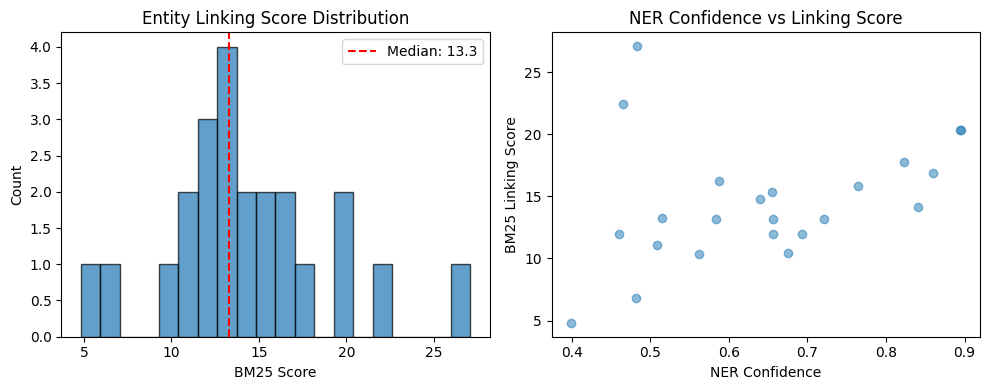

In [50]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(scores, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('BM25 Score')
plt.ylabel('Count')
plt.title('Entity Linking Score Distribution')
plt.axvline(x=np.median(scores), color='r', linestyle='--', label=f'Median: {np.median(scores):.1f}')
plt.legend()

plt.subplot(1, 2, 2)
# Score vs NER confidence
ner_scores = [r["ner_score"] for r in linked_results if r["top_icd_score"] > 0]
plt.scatter(ner_scores, scores, alpha=0.5)
plt.xlabel('NER Confidence')
plt.ylabel('BM25 Linking Score')
plt.title('NER Confidence vs Linking Score')

plt.tight_layout()
plt.savefig('entity_linking_analysis.png', dpi=150)
plt.show()

In [51]:
# Find low-confidence links for manual review
print("\nLOW CONFIDENCE LINKS (potential errors):")
print("=" * 70)

low_conf_results = [r for r in linked_results if 0 < r["top_icd_score"] <= 5]
low_conf_results.sort(key=lambda x: x["top_icd_score"])

for result in low_conf_results[:10]:
    print(f"\nEntity: '{result['entity_text']}'")
    print(f"  Best match: {result['top_icd_code']}: {result['top_icd_title']}")
    print(f"  Score: {result['top_icd_score']:.2f} (LOW)")
    print(f"  Possible issues: ", end="")
    
    # Diagnose potential issues
    if len(result['entity_text'].split()) == 1:
        print("Single word (ambiguous), ", end="")
    if result['entity_text'].lower() in ["sjukdom", "symtom", "besvär"]:
        print("Generic term, ", end="")
    print()


LOW CONFIDENCE LINKS (potential errors):

Entity: 'magen'
  Best match: F41.1: Generaliserat ångestsyndrom
  Score: 4.81 (LOW)
  Possible issues: Single word (ambiguous), 


### 4.5 Discussion: Entity Linking Results

**Strengths of BM25 approach:**
- Simple and interpretable
- No training data required
- Works well for exact/near-exact matches

**Limitations:**
- Struggles with synonyms (e.g., "hjärtattack" vs "hjärtinfarkt")
- Generic terms (e.g., "sjukdom", "inflammation") match many codes
- Abbreviations not handled

**Potential improvements:**
1. **Embedding-based retrieval**: Use multilingual medical embeddings for semantic matching
2. **Synonym expansion**: Expand queries with Swedish MeSH terms
3. **Context-aware linking**: Use surrounding sentence context
4. **Re-ranking**: Train a classifier to re-rank BM25 candidates